<img src="images/purple_net.jpeg" alt="purple_net"> 

# **<font color="purple">NN Image Classification -- Lab 4</font>**
### **<font color="purple">Prof. Tiziana Ligorio</font>**
### **<font color="purple">Hunter College of The City University of New York</font>**

---
---

In [ ]:
!pip install lightning torchinfo -q

# Make a copy of this notebook in your drive so you can edit it


In this lab we will **build an image classifier** using a fully connected feed forward neural network
on the Fashion MNIST dataset, using **PyTorch** and **PyTorch Lightning**.

We will do the following:
1. [Load and Partition the data into Training, Validation and Test set](#partition)
2. [Data Preprocessing](#preprocessing)
3. [Select and Train the Model](#model)
    * [Early Stopping](#earlystopping)
    * [Model Checkpoints](#checkpoints)
4. [Evaluate the Model](#evaluate)
5. [Save the Model](#save)
6. [TensorBoard](#tensorboard)

*This lab is adapted from [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow](https://github.com/ageron/handson-ml2) by Aurélien Géron.*

In [1]:
# import the packages we will use
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

import torchvision
import os

In [2]:
# Set random seeds for reproducibility
np.random.seed(15)
torch.manual_seed(15)
L.seed_everything(15, workers=True)

# With Lightning, the Trainer handles device placement automatically
# via Trainer(accelerator='auto'). You no longer need to manually call .to(device)
# on the model or move tensors inside the training loop.
#
# We still define `device` here for use in inference cells (predictions, evaluation)
# that run outside the Trainer.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed(15)
print(f'Using device: {device}')

Seed set to 15


Using device: cpu


<a id="partition"></a>
# Load and Partition into Training and Test set
---

For this task we will use the popular **Fashion MNIST** dataset: 70,000 grayscale images of clothing
items in 10 categories, each 28×28 pixels.

`torchvision.datasets.FashionMNIST` downloads and caches the dataset for us. It is already split into
a training set (60,000 images) and a test set (10,000 images). We will further split the training set
to carve out a **validation set** of 10,000 images:

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True)

# .data → uint8 tensor of pixel values; .targets → integer class labels
# Convert to numpy for easy slicing and plotting
X_train_full = train_dataset.data.numpy()     # shape: (60000, 28, 28)
y_train_full = train_dataset.targets.numpy()  # shape: (60000,)
X_test = test_dataset.data.numpy()            # shape: (10000, 28, 28)
y_test = test_dataset.targets.numpy()         # shape: (10000,)

In [4]:
type(X_train_full)

numpy.ndarray

In [5]:
X_train_full.shape

(60000, 28, 28)

In [6]:
X_test.shape

(10000, 28, 28)

The training set consists of 60K images, 28x28 pixels each.    
Let's partition the training set further to obtain a validation set. Since the test set consists of 10K images, let's partition out a validation set of 10K images as well.

In [7]:
# partition 10,000 instances into X_valid by slicing X_train_full
X_valid, X_train = X_train_full[:10000], X_train_full[10000:]
y_valid, y_train = y_train_full[:10000], y_train_full[10000:]

# sanity check
print(X_valid.shape)
print(X_train.shape)
print(X_train.dtype)

(10000, 28, 28)
(50000, 28, 28)
uint8


<a name="preprocessing"></a>
# Data Preprocessing
---

Each instance (image) is a 28×28 grid of integers representing grayscale color intensities (0 = black, 255 = white).
Let's look at a few pixels in the first image of our training set:

In [8]:
# print pixel values of the first image in X_train
print('Top-left corner pixel:', X_train[0][0, 0])
print('Center pixel:', X_train[0][14, 14])
print('Low-left pixel:', X_train[0][20, 2])

Top-left corner pixel: 0
Center pixel: 252
Low-left pixel: 131


Let's now take a look at the first image in our training set:

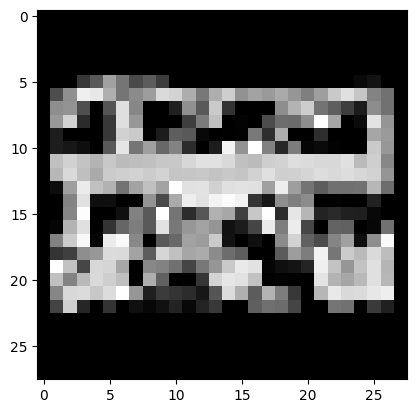

In [9]:
# plot the first image in X_train
plt.imshow(X_train[0], cmap='gray')  # grayscale images → gray color map
plt.show()

These are small images — it's very blurry, can you tell what it is?  

The actual labels are integers 0–9 corresponding to one of these class_names provided in the data documentation:

In [10]:
# here are the class names from the documentation in correct order
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [11]:
# what class does the label of the first training example map to?
class_names[y_train[0]]

'Bag'

In [12]:
y_train[0]

np.int64(8)

Since the pixels are integers between 0 and 255, we can **scale in the range [0,1]** simply by dividing:

In [13]:
X_valid, X_train = X_valid / 255., X_train / 255.
X_test = X_test / 255.

Center pixel: 0.9882352941176471


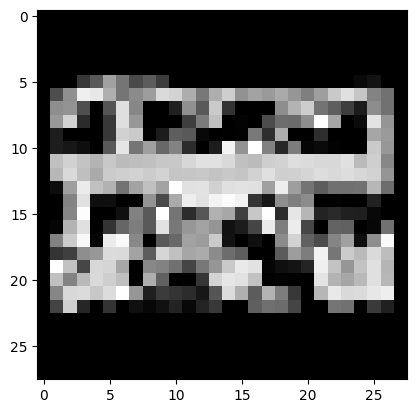

In [14]:
# plot again the first image in the training set
print('Center pixel:', X_train[0][14, 14])
plt.imshow(X_train[0], cmap='gray')
plt.show()

# the image looks just the same; we have only changed the scale

To give you a better sense of the data, let's plot a few more images.  
It is helpful to invert the grayscale when plotting (it makes no difference to the model):

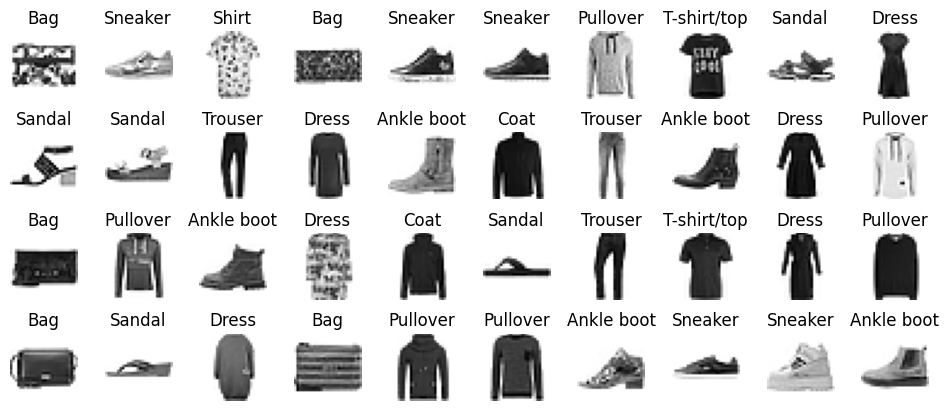

In [15]:
#@title Visualization Code

# plot 4 rows of 10 images each
n_rows = 4
n_cols = 10

plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap='gray_r')
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

<a id="model"></a>
# Select and Train the model
---

Now that we know what our data looks like and we have scaled it, we are ready to build our classifier!

## Building the model 

In [16]:
def build_model():
    """
    Returns a 3-layer fully connected network as an nn.Sequential.

    Each hidden layer is two modules in sequence:
      - nn.Linear(in, out)  — computes the affine transformation W @ x + b
      - nn.ReLU()           — applies the non-linear activation element-wise

    Together they form one fully connected layer. PyTorch keeps them separate
    because the Linear module holds the learnable parameters (weights and biases)
    while ReLU has none — separating them makes the parameter count explicit.

    The output layer has no activation: nn.CrossEntropyLoss applies
    log-softmax internally during training.
    """
    return nn.Sequential(
        nn.Flatten(),           # 28×28 image → 784-element vector
        nn.Linear(784, 300),    # fully connected layer 1 (affine part)
        nn.ReLU(),              # fully connected layer 1 (activation)
        nn.Linear(300, 300),    # fully connected layer 2 (affine part)
        nn.ReLU(),              # fully connected layer 2 (activation)
        nn.Linear(300, 10)      # output layer — 10 raw logits, one per class
    )

In [17]:
class EpochProgressBar(L.Callback):
    """Prints one line per epoch with train and val metrics.
    on_train_epoch_end fires after validation, so both sets of metrics are available.
    """
    def on_train_epoch_end(self, trainer, pl_module):
        m     = trainer.callback_metrics
        epoch = trainer.current_epoch + 1
        total = trainer.max_epochs
        print(f'Epoch {epoch}/{total}'
              f'  loss: {m.get("train_loss", float("nan")):.4f}'
              f'  acc: {m.get("train_acc", float("nan")):.4f}'
              f'  val_loss: {m.get("val_loss", float("nan")):.4f}'
              f'  val_acc: {m.get("val_acc", float("nan")):.4f}')

In [18]:
class FashionClassifier(L.LightningModule):
    """
    LightningModule for FashionMNIST image classification.

    Encapsulates the model, loss, optimizer, and train/val/test logic.
    The Trainer calls training_step, validation_step, and test_step;
    no manual loop is needed.
    """
    def __init__(self):
        super().__init__()
        self.model     = build_model()
        self.criterion = nn.CrossEntropyLoss()
        self.history   = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        X, y  = batch
        out   = self(X)
        loss  = self.criterion(out, y)
        acc   = (out.argmax(dim=1) == y).float().mean()
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('train_acc',  acc,  on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y  = batch
        out   = self(X)
        loss  = self.criterion(out, y)
        acc   = (out.argmax(dim=1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  acc,  prog_bar=True)

    def test_step(self, batch, batch_idx):
        X, y  = batch
        out   = self(X)
        loss  = self.criterion(out, y)
        acc   = (out.argmax(dim=1) == y).float().mean()
        self.log('test_loss', loss)
        self.log('test_acc',  acc)

    def on_train_epoch_end(self):
        # Fires after validation; both train and val metrics are available
        m = self.trainer.callback_metrics
        self.history['loss'].append(m['train_loss'].item())
        self.history['accuracy'].append(m['train_acc'].item())
        self.history['val_loss'].append(m['val_loss'].item())
        self.history['val_accuracy'].append(m['val_acc'].item())

    def configure_optimizers(self):
        return optim.SGD(self.parameters(), lr=0.01)


# instantiate for architecture inspection (cells below)
classifier = FashionClassifier()

### Other optimizer options
* SGD — stochastic gradient descent, the fundamental optimizer    
`optim.SGD(self.parameters(), lr=0.01)`

* SGD with momentum — smooths updates by accumulating a velocity vector; often outperforms plain SGD  
`optim.SGD(self.parameters(), lr=0.01, momentum=0.9)`

* Adam — adaptive learning rates per parameter; converges faster than SGD, much less sensitive to the choice of lr; **the most widely used optimizer**
`optim.Adam(self.parameters(), lr=0.001)`

Let's inspect the model architecture with `torchinfo.summary()`, which shows each layer's
output shape and parameter count:

In [19]:
from torchinfo import summary

# input_size = (batch_size, height, width)
summary(classifier, input_size=(1, 28, 28), col_names=['output_size', 'num_params'])

Layer (type:depth-idx)                   Output Shape              Param #
FashionClassifier                        [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 784]                  --
│    └─Linear: 2-2                       [1, 300]                  235,500
│    └─ReLU: 2-3                         [1, 300]                  --
│    └─Linear: 2-4                       [1, 300]                  90,300
│    └─ReLU: 2-5                         [1, 300]                  --
│    └─Linear: 2-6                       [1, 10]                   3,010
Total params: 328,810
Trainable params: 328,810
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.33
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 1.32
Estimated Total Size (MB): 1.32

The first `nn.Linear` module connects 784 (= 28×28) inputs to 300 hidden units:
784 × 300 weights + 300 biases = **235,500 parameters**.

Every `nn.Linear` exposes its parameters as:
* `layer.weight` — shape `(out_features, in_features)`
* `layer.bias`   — shape `(out_features,)`

Let's inspect the first hidden layer's `nn.Linear` module (index 1 in the Sequential,
after `Flatten` at index 0):

In [20]:
# classifier.model is the inner nn.Sequential returned by build_model()
# list(classifier.model.children()) gives its sub-modules in order:
#   [Flatten, Linear(784,300), ReLU, Linear(300,300), ReLU, Linear(300,10)]
hidden1 = list(classifier.model.children())[1]  # nn.Linear(784, 300)
hidden1

Linear(in_features=784, out_features=300, bias=True)

In [21]:
hidden1.__class__.__name__

'Linear'

In [22]:
# .detach() stops gradient tracking
# .cpu()    moves the tensor from GPU to CPU (required before calling .numpy())
# .numpy()  converts to a numpy array
#
# Even if you are on CPU, .cpu() is a no-op, so this pattern is always safe.
weights = hidden1.weight.detach().cpu().numpy()
biases  = hidden1.bias.detach().cpu().numpy()

In [23]:
weights

array([[-0.01447647, -0.01595747,  0.02123974, ...,  0.00603618,
        -0.00997504,  0.0140174 ],
       [ 0.00319139, -0.02084537, -0.01060108, ..., -0.02752323,
         0.02575419,  0.03313476],
       [-0.03082683,  0.03198351,  0.00560779, ..., -0.03507205,
        -0.0065202 ,  0.01196817],
       ...,
       [ 0.02932328, -0.01220983,  0.03536537, ..., -0.01909615,
         0.00346716, -0.02759586],
       [ 0.00910516, -0.00049483, -0.00322327, ..., -0.03547512,
        -0.01593093,  0.01625653],
       [ 0.03353619, -0.03367171, -0.01416389, ..., -0.01853887,
        -0.02328195,  0.02509005]], shape=(300, 784), dtype=float32)

In [24]:
# (300, 784) — out_features × in_features
weights.shape

(300, 784)

In [25]:
biases

array([ 0.027303  , -0.00785065, -0.02220353, -0.02645477, -0.01593959,
       -0.00309852,  0.03003284, -0.01494557,  0.00044731,  0.02757108,
        0.01037507, -0.01299992, -0.03390781,  0.02681798, -0.00579396,
       -0.02281649,  0.02365527, -0.02966194, -0.02494813,  0.02830685,
       -0.00971836,  0.02889918, -0.01279528, -0.02301201, -0.01358976,
       -0.02840248, -0.01370853,  0.02081347, -0.03474214,  0.03207324,
        0.03553398,  0.01947748, -0.01737381,  0.01391743,  0.0294479 ,
       -0.01032866,  0.02817079,  0.00898176, -0.0056237 , -0.01078033,
        0.00610323,  0.03499862, -0.02244622, -0.00085818,  0.01120758,
       -0.00274232,  0.00412993, -0.01371876, -0.02050979, -0.01943598,
       -0.03063448, -0.01132529, -0.02398475,  0.00780961, -0.031645  ,
       -0.00894325, -0.02092716, -0.01209766, -0.00868262, -0.01481158,
        0.03300335,  0.02002899,  0.00119699, -0.03036235,  0.00321124,
       -0.00499193,  0.01662849,  0.02355732, -0.01582548, -0.01

In [26]:
biases.shape

(300,)

Notice we have not trained the network yet — these are the **initial random weights**.

**PyTorch default initialisation:** 
* Kaiming (He) uniform for weights
* small uniform distribution for biases   

This is designed to preserve activation variance across layers in the presence of ReLU.

In [27]:
def get_loader(X, y, batch_size=32, shuffle=True):
    """Wrap numpy arrays in a PyTorch DataLoader with batch_size=32 (Lightning default)."""
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

In [28]:
train_loader = get_loader(X_train, y_train)
val_loader   = get_loader(X_valid, y_valid, shuffle=False)

classifier = FashionClassifier()

# Trainer replaces the manual epoch/batch loop.
#   accelerator="auto"      → GPU if available, CPU otherwise
#   enable_progress_bar=False + EpochProgressBar → one clean line per epoch
trainer = L.Trainer(
    max_epochs=15,
    accelerator='auto',
    enable_model_summary=False,
    callbacks=[EpochProgressBar()],
    enable_progress_bar=False
)

trainer.fit(classifier, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the

Epoch 1/15  loss: 1.1035  acc: 0.6428  val_loss: 0.6772  val_acc: 0.7576
Epoch 2/15  loss: 0.5986  acc: 0.7903  val_loss: 0.5350  val_acc: 0.8151
Epoch 3/15  loss: 0.5149  acc: 0.8184  val_loss: 0.5087  val_acc: 0.8198
Epoch 4/15  loss: 0.4771  acc: 0.8325  val_loss: 0.4737  val_acc: 0.8337
Epoch 5/15  loss: 0.4519  acc: 0.8416  val_loss: 0.4415  val_acc: 0.8456
Epoch 6/15  loss: 0.4324  acc: 0.8482  val_loss: 0.4550  val_acc: 0.8399
Epoch 7/15  loss: 0.4172  acc: 0.8524  val_loss: 0.4189  val_acc: 0.8533
Epoch 8/15  loss: 0.4034  acc: 0.8594  val_loss: 0.4057  val_acc: 0.8566
Epoch 9/15  loss: 0.3922  acc: 0.8629  val_loss: 0.4195  val_acc: 0.8510
Epoch 10/15  loss: 0.3810  acc: 0.8667  val_loss: 0.3835  val_acc: 0.8651
Epoch 11/15  loss: 0.3710  acc: 0.8675  val_loss: 0.3884  val_acc: 0.8599
Epoch 12/15  loss: 0.3631  acc: 0.8703  val_loss: 0.3918  val_acc: 0.8606
Epoch 13/15  loss: 0.3537  acc: 0.8749  val_loss: 0.3815  val_acc: 0.8664
Epoch 14/15  loss: 0.3464  acc: 0.8762  val_los

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 15/15  loss: 0.3387  acc: 0.8789  val_loss: 0.4094  val_acc: 0.8536


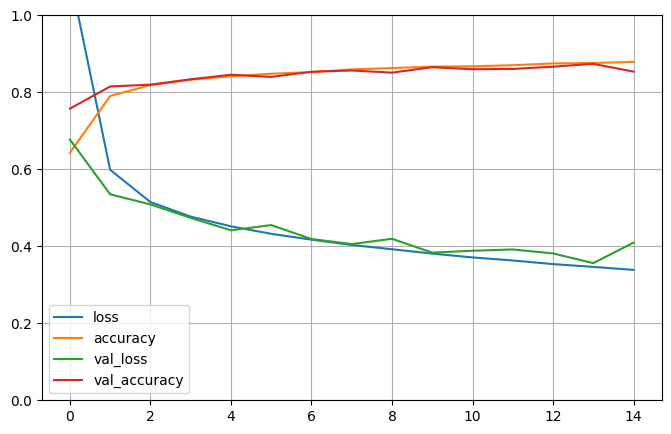

In [ ]:
# classifier.history is populated by on_train_epoch_end() after each epoch
pd.DataFrame(classifier.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

Notice the `accuracy` vs `val_accuracy` and `loss` vs `val_loss`. Training metrics keep
improving, but validation metrics may tell a different story — a sign of **overfitting**.
Our choice of 15 epochs is arbitrary; looking at these curves side by side is a good way
to decide when the model stops generalising.

Keep in mind: the validation set is used to guide training decisions (e.g. when to stop).
It is **not** an unbiased estimate of the model's true performance — that is the test set.

<a name="earlystopping"></a>
## Early Stopping

Let's retrain with a large epoch budget and let **early stopping** decide when to stop.

`EarlyStopping` is a built-in Lightning callback. It monitors a metric (`val_loss`) and
halts training when there is no improvement greater than `min_delta` for `patience`
consecutive epochs. Lightning automatically restores the weights from the best epoch.

**Always re-instantiate `FashionClassifier()` to reset the weights before re-training.**

In [30]:
# EarlyStopping parameters:
#   monitor                    → metric to watch
#   mode='min'                 → lower is better
#   patience                   → epochs without improvement before stopping
#   min_delta                  → minimum change that counts as improvement
#   check_on_train_epoch_end=False → check after validation, not after training
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    min_delta=0.01,
    check_on_train_epoch_end=False,
    verbose=True
)

classifier = FashionClassifier()

In [31]:
train_loader = get_loader(X_train, y_train)
val_loader   = get_loader(X_valid, y_valid, shuffle=False)

# max_epochs is a safety ceiling; EarlyStopping will stop training earlier.
trainer = L.Trainer(
    max_epochs=300,
    accelerator='auto',
    enable_model_summary=False,
    callbacks=[EpochProgressBar(), early_stop_cb],
    enable_progress_bar=False
)

trainer.fit(classifier, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the

Epoch 1/300  loss: 1.1097  acc: 0.6478  val_loss: 0.6869  val_acc: 0.7523


Metric val_loss improved by 0.136 >= min_delta = 0.01. New best score: 0.551


Epoch 2/300  loss: 0.5927  acc: 0.7944  val_loss: 0.5511  val_acc: 0.8088


Metric val_loss improved by 0.044 >= min_delta = 0.01. New best score: 0.507


...

Epoch 21/300  loss: 0.3034  acc: 0.8900  val_loss: 0.3353  val_acc: 0.8800
Epoch 22/300  loss: 0.2980  acc: 0.8927  val_loss: 0.3368  val_acc: 0.8817
Epoch 23/300  loss: 0.2932  acc: 0.8945  val_loss: 0.3278  val_acc: 0.8816
Epoch 24/300  loss: 0.2886  acc: 0.8958  val_loss: 0.3473  val_acc: 0.8671


Metric val_loss improved by 0.016 >= min_delta = 0.01. New best score: 0.319


Epoch 25/300  loss: 0.2835  acc: 0.8972  val_loss: 0.3190  val_acc: 0.8887
Epoch 26/300  loss: 0.2793  acc: 0.8988  val_loss: 0.3187  val_acc: 0.8886
Epoch 27/300  loss: 0.2755  acc: 0.9004  val_loss: 0.3456  val_acc: 0.8784
Epoch 28/300  loss: 0.2710  acc: 0.9015  val_loss: 0.3471  val_acc: 0.8769
Epoch 29/300  loss: 0.2664  acc: 0.9032  val_loss: 0.3122  val_acc: 0.8841


Monitored metric val_loss did not improve in the last 5 records. Best score: 0.319. Signaling Trainer to stop.


Epoch 30/300  loss: 0.2630  acc: 0.9043  val_loss: 0.3167  val_acc: 0.8843


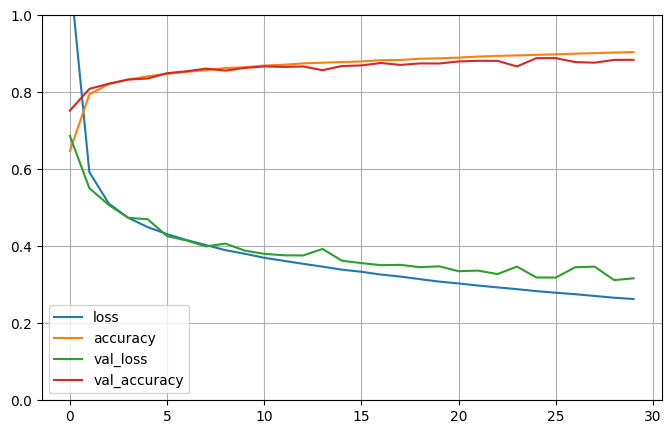

In [32]:
pd.DataFrame(classifier.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

Observing this plot we can see the training and validation curves eventually diverge,
triggering early stopping.

As we will discuss in Lecture 7, very large networks sometimes exhibit **double descent**:
the loss decreases, then rises, then decreases again to an even better minimum. Early
stopping at the first sign of ascent can prevent the model from finding that second, better
minimum. An alternative is to train for many epochs while saving **checkpoints** of the best
weights.

<a name="checkpoints"></a>
## Model Checkpoints

`ModelCheckpoint` is a built-in Lightning callback that saves the model whenever the
monitored metric improves. It saves a **full Lightning checkpoint** (weights + optimiser
state + training metadata), which can be reloaded with a single call:

```python
classifier = FashionClassifier.load_from_checkpoint(checkpoint_cb.best_model_path)
```

After training, `checkpoint_cb.best_model_path` gives the path of the best saved file.

Checkpoints are saved locally (`./checkpoints/`). This works both on your machine and in
Colab (for the duration of the session). To persist them across Colab disconnects, change
`dirpath` to a Google Drive path.

In [33]:
EPOCHS         = 30
model_name     = 'mnist_dense_checkpoints'
checkpoint_dir = './checkpoints'

checkpoint_cb = ModelCheckpoint(
    dirpath=checkpoint_dir,
    filename=model_name + '-{epoch:02d}-{val_loss:.2f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    verbose=True
)

# Re-instantiate to reset all weights before re-training
classifier = FashionClassifier()

In [34]:
train_loader = get_loader(X_train, y_train)
val_loader   = get_loader(X_valid, y_valid, shuffle=False)

trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator='auto',
    callbacks=[EpochProgressBar(), checkpoint_cb],
    enable_progress_bar=False,
    num_sanity_val_steps=0
)

trainer.fit(classifier, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/tizianaligorio/dev/deeplearning_notebooks/deep_learning_intro_torch_tutorials/checkpoints exists and is not empty.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | Sequential       | 328 K  | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
328 K     Trainable params
0         Non-trainable params
328 K     Total params
1.315     Total estimated m

Epoch 1/30  loss: 1.1165  acc: 0.6340  val_loss: 0.6797  val_acc: 0.7671


Epoch 1, global step 3126: 'val_loss' reached 0.53991 (best 0.53991), saving model to '/Users/tizianaligorio/dev/deeplearning_notebooks/deep_learning_intro_torch_tutorials/checkpoints/mnist_dense_checkpoints-epoch=01-val_loss=0.54.ckpt' as top 1


Epoch 2/30  loss: 0.5970  acc: 0.7923  val_loss: 0.5399  val_acc: 0.8188


Epoch 2, global step 4689: 'val_loss' reached 0.48615 (best 0.48615), saving model to '/Users/tizianaligorio/dev/deeplearning_notebooks/deep_learning_intro_torch_tutorials/checkpoints/mnist_dense_checkpoints-epoch=02-val_loss=0.49.ckpt' as top 1


...

Epoch 28/30  loss: 0.2706  acc: 0.9024  val_loss: 0.3113  val_acc: 0.8896


Epoch 28, global step 45327: 'val_loss' was not in top 1


Epoch 29/30  loss: 0.2651  acc: 0.9045  val_loss: 0.3133  val_acc: 0.8847


Epoch 29, global step 46890: 'val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30  loss: 0.2614  acc: 0.9057  val_loss: 0.3317  val_acc: 0.8802


`checkpoint_cb.best_model_path` holds the path of the best saved checkpoint.
`load_from_checkpoint()` reconstructs the model architecture and loads the weights
in a single call — no need to re-instantiate the class manually first.

In [35]:
print('Best checkpoint:', checkpoint_cb.best_model_path)

classifier = FashionClassifier.load_from_checkpoint(checkpoint_cb.best_model_path)
classifier.eval()

Best checkpoint: /Users/tizianaligorio/dev/deeplearning_notebooks/deep_learning_intro_torch_tutorials/checkpoints/mnist_dense_checkpoints-epoch=27-val_loss=0.31-v4.ckpt


FashionClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=300, bias=True)
    (4): ReLU()
    (5): Linear(in_features=300, out_features=10, bias=True)
  )
  (criterion): CrossEntropyLoss()
)

<a name="evaluate"></a>
## Evaluate the Model
---

Our "best model" is the one that performed best on the **validation set**. The validation
set guided training decisions (early stopping, checkpoint selection), so it is not an
unbiased measure of generalisation. The final, unbiased estimate comes from the **test set**,
which the model has never seen.

`trainer.test()` runs `test_step()` over the test DataLoader and aggregates the logged metrics.

In [36]:
test_loader = get_loader(X_test, y_test, shuffle=False)

test_results = trainer.test(classifier, test_loader, verbose=True)
print(f"Test loss: {test_results[0]['test_loss']:.4f}  "
      f"Test accuracy: {test_results[0]['test_acc']:.4f}")

/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.878600001335144
        test_loss           0.3396137058734894
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test loss: 0.3396  Test accuracy: 0.8786


Let's look at what the model actually predicts for a few examples.

The model outputs raw **logits** (one per class). We apply `torch.softmax(logits, dim=1)`
to convert them to class probabilities. Note the `.cpu()` call before `.numpy()` — this is
required whenever a tensor may be on GPU.

In [37]:
X_mini   = X_test[:3]
X_mini_t = torch.FloatTensor(X_mini).to(classifier.device)

classifier.eval()
with torch.no_grad():
    logits      = classifier(X_mini_t)
    predictions = torch.softmax(logits, dim=1).cpu().numpy()

predictions.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.04, 0.  , 0.94],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

`softmax` forces the outputs to sum to 1, giving the network's confidence for each class.
`argmax` extracts the index of the highest probability — that is the predicted class.

In [38]:
y_hat = np.argmax(predictions, axis=1)
y_hat

array([9, 2, 1])

In [39]:
np.array(class_names)[y_hat]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [40]:
y_mini = y_test[:3]
y_mini

array([9, 2, 1])

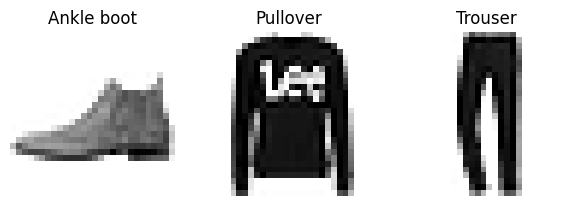

In [41]:
#@title Visualization Code
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_mini):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap='gray_r')
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

<a name="save"></a>
# Save the Model
---

We save only the model **weights** using `torch.save(model.state_dict(), path)`.

**Why `state_dict` and not `torch.save(model, path)`?**
`state_dict()` is a plain dictionary of tensors. It loads safely with `weights_only=True`,
which is the secure default in PyTorch 2.6+. Saving the full model object uses `pickle`
and raises a security warning.

Reloading always follows a two-step pattern:
```python
saved_model = FashionClassifier()                               # 1. fresh architecture
saved_model.load_state_dict(torch.load(path, weights_only=True))  # 2. load weights
```

In [42]:
model_save_path = './checkpoints/fashion_mnist_model.pt'

torch.save(classifier.state_dict(), model_save_path)
print(f'Model saved to {model_save_path}')

Model saved to ./checkpoints/fashion_mnist_model.pt


In [43]:
saved_model = FashionClassifier()
saved_model.load_state_dict(
    torch.load(model_save_path, weights_only=True, map_location=device)
)
saved_model.eval()

FashionClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=300, bias=True)
    (4): ReLU()
    (5): Linear(in_features=300, out_features=10, bias=True)
  )
  (criterion): CrossEntropyLoss()
)

In [44]:
X_15 = torch.FloatTensor(X_test[15:16]).to(saved_model.device)
with torch.no_grad():
    logits_15 = saved_model(X_15)
    probs_15  = torch.softmax(logits_15, dim=1).cpu().numpy()

probs_15.round(2)

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [45]:
# print the class name corresponding to the true label of the 15th image
np.array(class_names)[y_test[15:16]]

array(['Trouser'], dtype='<U11')

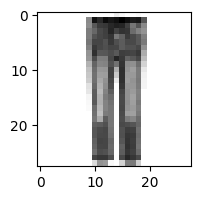

In [46]:
plt.figure(figsize=(2, 2))
plt.imshow(X_test[15], cmap='gray_r')
plt.show()

# We can do better!
Recall what we did: we flattened the image into a sequence of 784 pixels on the input layer. It's amazing that a dense network can predict images this well, but this is a relatively simple dataset. This network would not work as well with more complex, color images. Modern computer vision uses a different architecture for processing images, Convolutional Neural Networks (CNNs), which are inspired by the way the human visual system works — rather than flattening the image, it preserves the 2D grid structure and detects local patterns like edges and shapes, gradually combining them to recognize more complex          
structures.